<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/004_mnist_mlp_vs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Quanto a estrutura espacial importa na classificação de imagens?

**Área:** Deep Learning  
**Nível:** 🟡 Intermediate  
**Tipo de problema:** Classificação multiclasse de imagens

### Pergunta de estudo

> Uma rede convolucional (CNN) classifica dígitos manuscritos melhor do que uma rede totalmente conectada (MLP) quando ambas recebem o mesmo conjunto de imagens?

### Modelos

1. MLP — baseline;
2. CNN — modelo que explora a estrutura espacial das imagens.

### Métricas

- Accuracy;
- Precision, Recall e F1 por classe;
- matriz de confusão.

O MNIST possui dez classes, correspondentes aos dígitos de 0 a 9.


## 1. Configuração do ambiente

O TensorFlow/Keras já costuma estar disponível no Google Colab.


In [1]:
# Importações.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
)
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Carregamento do MNIST

O MNIST contém imagens em tons de cinza com dimensão `28 × 28`.

O conjunto original fornece:

- 60.000 imagens de treino;
- 10.000 imagens de teste.

Uma parte do treino será separada para validação.


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Treino original:", x_train_full.shape, y_train_full.shape)
print("Teste:", x_test.shape, y_test.shape)


Treino original: (60000, 28, 28) (60000,)
Teste: (10000, 28, 28) (10000,)


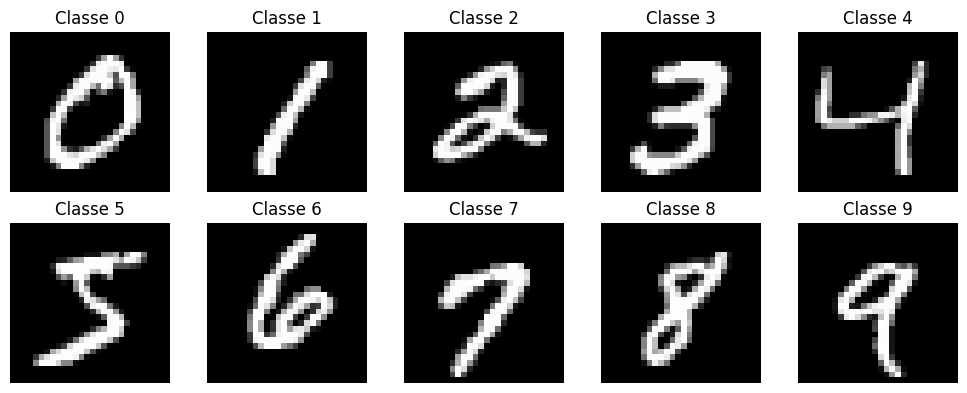

In [3]:
# Exibe uma amostra de imagens.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.ravel()):
    idx = np.where(y_train_full == digit)[0][0]
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(f"Classe {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Preparação dos dados

Os pixels são convertidos de `[0, 255]` para `[0, 1]`.

Também será criado um conjunto de validação estratificado a partir do treinamento original.


In [4]:
# Normaliza os pixels.
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Cria treino e validação preservando a distribuição das classes.
train_idx, val_idx = train_test_split(
    np.arange(len(x_train_full)),
    test_size=10_000,
    random_state=SEED,
    stratify=y_train_full,
)

x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]

x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]

print("Treino:", x_train.shape)
print("Validação:", x_val.shape)
print("Teste:", x_test.shape)


Treino: (50000, 28, 28)
Validação: (10000, 28, 28)
Teste: (10000, 28, 28)


## 4. Baseline — MLP

A MLP recebe a imagem achatada em um vetor de 784 valores.

Essa transformação perde explicitamente a noção de vizinhança espacial entre pixels, embora a rede ainda possa aprender padrões úteis.


In [5]:
mlp_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.25),
    Dense(10, activation="softmax"),
])

mlp_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stopping_mlp = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

mlp_history = mlp_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping_mlp],
    verbose=1,
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8739 - loss: 0.4446 - val_accuracy: 0.9355 - val_loss: 0.2291
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9377 - loss: 0.2171 - val_accuracy: 0.9534 - val_loss: 0.1682
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9501 - loss: 0.1696 - val_accuracy: 0.9611 - val_loss: 0.1395
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9594 - loss: 0.1382 - val_accuracy: 0.9651 - val_loss: 0.1228
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9648 - loss: 0.1198 - val_accuracy: 0.9680 - val_loss: 0.1121
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9693 - loss: 0.1047 - val_accuracy: 0.9708 - val_loss: 0.1009
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9710 - loss: 0.0936 - val_accuracy: 0.9724 - val_loss: 0.0982
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0821 - val_accuracy: 0

## 5. CNN — Convolutional Neural Network

A CNN preserva a estrutura bidimensional da imagem.

As camadas convolucionais aprendem filtros locais; as camadas de pooling reduzem a resolução espacial mantendo padrões relevantes.


In [7]:
# Adiciona a dimensão de canal esperada pelas convoluções.
x_train_cnn = x_train[..., np.newaxis]
x_val_cnn = x_val[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

cnn_model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, kernel_size=3, activation="relu"),
    MaxPooling2D(pool_size=2),

    Conv2D(64, kernel_size=3, activation="relu"),
    MaxPooling2D(pool_size=2),

    Dropout(0.25),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(10, activation="softmax"),
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping_cnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping_cnn],
    verbose=1,
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.9083 - loss: 0.2973 - val_accuracy: 0.9768 - val_loss: 0.0746
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9730 - loss: 0.0854 - val_accuracy: 0.9828 - val_loss: 0.0524
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9805 - loss: 0.0622 - val_accuracy: 0.9843 - val_loss: 0.0484
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.9839 - loss: 0.0520 - val_accuracy: 0.9873 - val_loss: 0.0401
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9878 - loss: 0.0412 - val_accuracy: 0.9879 - val_loss: 0.0367
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9877 - val_loss: 0.0432
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.9902 - loss: 0.0325 - val_accuracy: 0.9892 - val_loss: 0.0388
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.9895 - loss: 0.0307 - 

## 6. Curvas de treinamento

As curvas permitem observar convergência e sinais de overfitting.


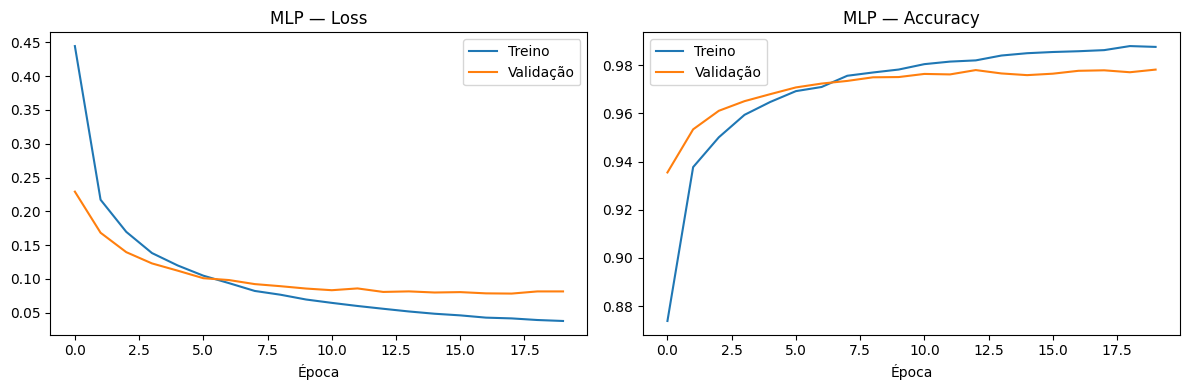

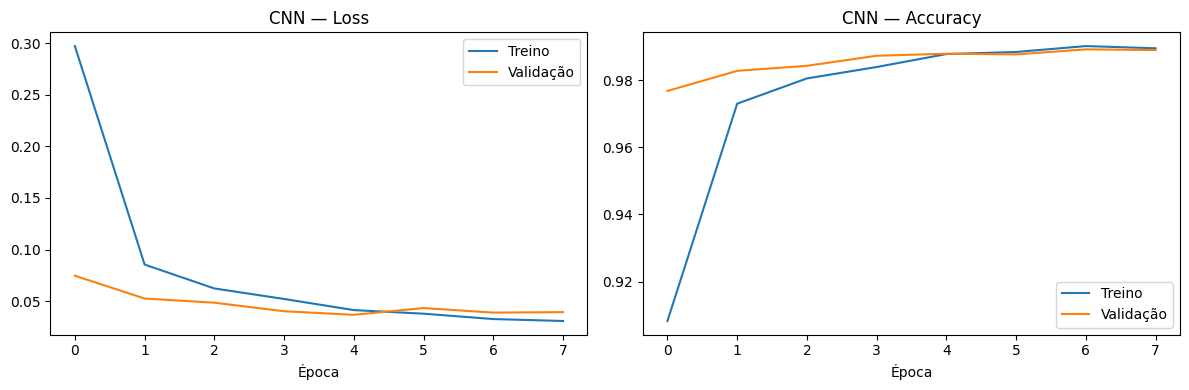

In [9]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["loss"], label="Treino")
    axes[0].plot(history_df["val_loss"], label="Validação")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="Treino")
    axes[1].plot(history_df["val_accuracy"], label="Validação")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(mlp_history, "MLP")
plot_history(cnn_history, "CNN")


## 7. Avaliação final

O conjunto de teste não foi utilizado no ajuste dos modelos.


In [10]:
# Predições.
mlp_probabilities = mlp_model.predict(x_test, verbose=0)
cnn_probabilities = cnn_model.predict(x_test_cnn, verbose=0)

mlp_predictions = mlp_probabilities.argmax(axis=1)
cnn_predictions = cnn_probabilities.argmax(axis=1)

mlp_accuracy = accuracy_score(y_test, mlp_predictions)
cnn_accuracy = accuracy_score(y_test, cnn_predictions)

results = pd.DataFrame({
    "Modelo": ["MLP", "CNN"],
    "Accuracy": [mlp_accuracy, cnn_accuracy],
    "Parâmetros": [mlp_model.count_params(), cnn_model.count_params()],
}).set_index("Modelo")

display(results)


,Accuracy,Parâmetros
Modelo,,
MLP,0.9791,101770
CNN,0.9909,225034


In [11]:
print("MLP")
print(classification_report(y_test, mlp_predictions, digits=4))

print("\nCNN")
print(classification_report(y_test, cnn_predictions, digits=4))


MLP
              precision    recall  f1-score   support

           0     0.9798    0.9918    0.9858       980
           1     0.9903    0.9912    0.9908      1135
           2     0.9814    0.9729    0.9771      1032
           3     0.9579    0.9911    0.9742      1010
           4     0.9816    0.9786    0.9801       982
           5     0.9885    0.9664    0.9773       892
           6     0.9832    0.9802    0.9817       958
           7     0.9804    0.9718    0.9761      1028
           8     0.9723    0.9713    0.9718       974
           9     0.9761    0.9732    0.9747      1009

    accuracy                         0.9791     10000
   macro avg     0.9792    0.9788    0.9790     10000
weighted avg     0.9792    0.9791    0.9791     10000


CNN
              precision    recall  f1-score   support

           0     0.9889    0.9959    0.9924       980
           1     0.9904    0.9974    0.9939      1135
           2     0.9941    0.9864    0.9903      1032
           3   

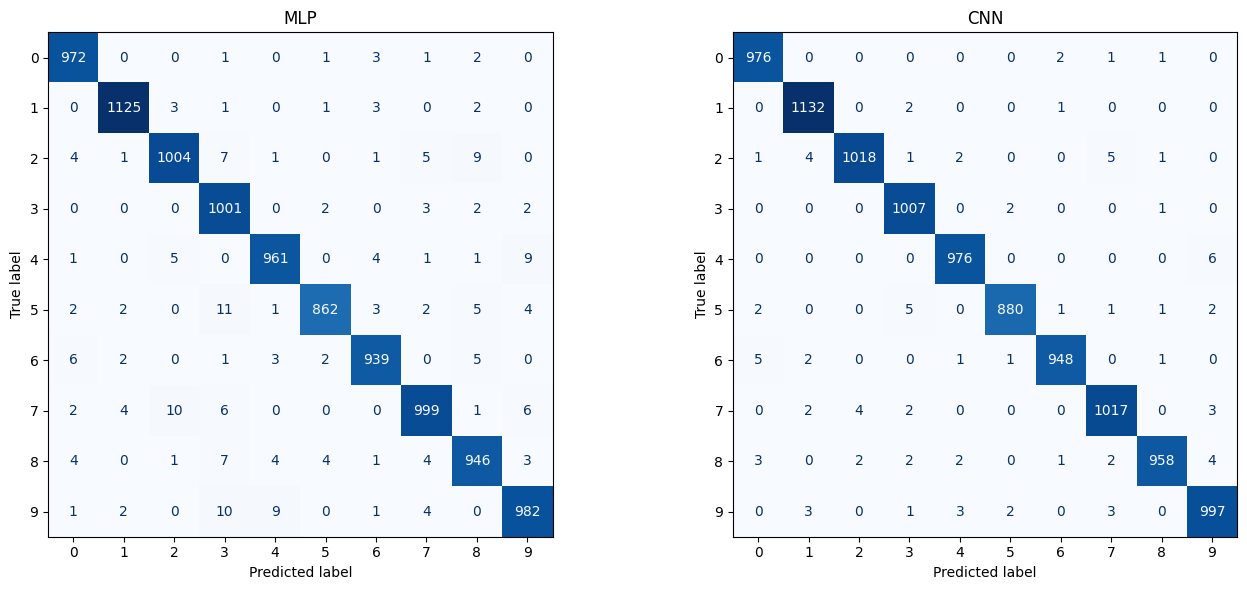

In [12]:
# Matrizes de confusão.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    mlp_predictions,
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("MLP")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    cnn_predictions,
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("CNN")

plt.tight_layout()
plt.show()


## 8. Análise de erros da CNN

Visualizar erros ajuda a compreender quais dígitos o modelo confunde e se os exemplos são ambíguos até mesmo para humanos.


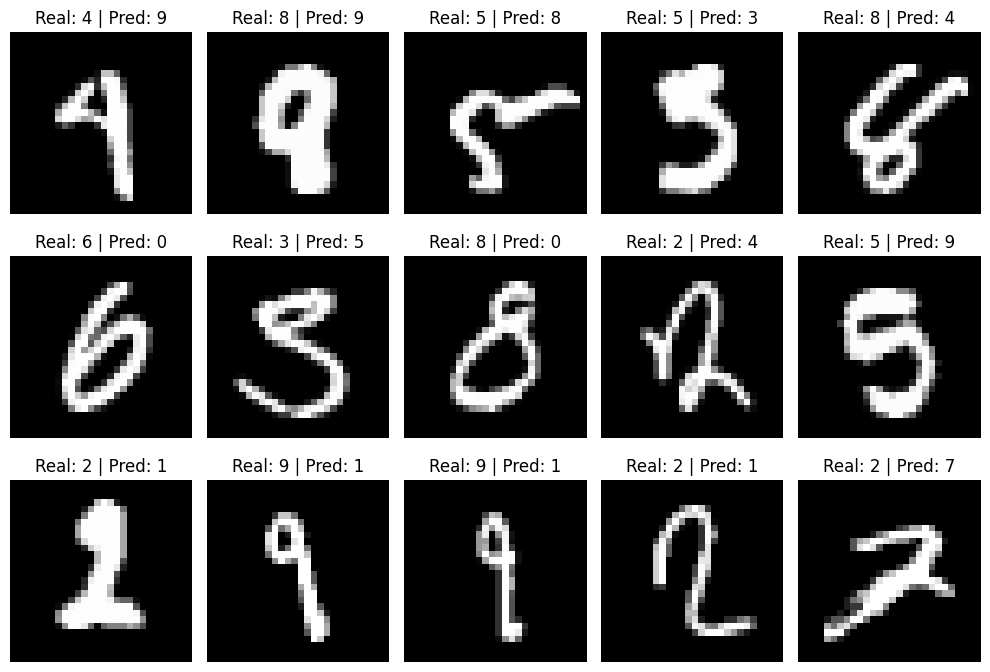

In [13]:
wrong_indices = np.where(cnn_predictions != y_test)[0]

rng = np.random.default_rng(SEED)
sample_size = min(15, len(wrong_indices))
sample_indices = rng.choice(wrong_indices, size=sample_size, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(10, 7))

for idx, ax in zip(sample_indices, axes.ravel()):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"Real: {y_test[idx]} | Pred: {cnn_predictions[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 9. Conclusão


In [14]:
from IPython.display import Markdown, display

gain = (cnn_accuracy - mlp_accuracy) * 100

conclusion = f'''
### Síntese dos resultados

- **Accuracy da MLP:** {mlp_accuracy:.4f}
- **Accuracy da CNN:** {cnn_accuracy:.4f}
- **Diferença absoluta:** {gain:+.2f} pontos percentuais

A comparação mostra empiricamente o efeito de usar uma arquitetura que preserva e explora a estrutura espacial da imagem.

### Interpretação

A MLP recebe todos os pixels como um vetor. Já a CNN aplica filtros locais compartilhados ao longo da imagem, permitindo detectar padrões como bordas, traços e formas em diferentes posições.

### Limitações

- MNIST é um problema relativamente simples;
- as imagens são pequenas, centralizadas e com pouco ruído;
- não houve tuning sistemático de hiperparâmetros;
- o número de parâmetros, tempo e custo computacional também devem ser considerados na comparação.

### Próximos experimentos

1. Fashion-MNIST;
2. data augmentation;
3. Batch Normalization;
4. arquiteturas mais profundas;
5. avaliar robustez a rotação, ruído e deslocamento.
'''

display(Markdown(conclusion))



### Síntese dos resultados

- **Accuracy da MLP:** 0.9791
- **Accuracy da CNN:** 0.9909
- **Diferença absoluta:** +1.18 pontos percentuais

A comparação mostra empiricamente o efeito de usar uma arquitetura que preserva e explora a estrutura espacial da imagem.

### Interpretação

A MLP recebe todos os pixels como um vetor. Já a CNN aplica filtros locais compartilhados ao longo da imagem, permitindo detectar padrões como bordas, traços e formas em diferentes posições.

### Limitações

- MNIST é um problema relativamente simples;
- as imagens são pequenas, centralizadas e com pouco ruído;
- não houve tuning sistemático de hiperparâmetros;
- o número de parâmetros, tempo e custo computacional também devem ser considerados na comparação.

### Próximos experimentos

1. Fashion-MNIST;
2. data augmentation;
3. Batch Normalization;
4. arquiteturas mais profundas;
5. avaliar robustez a rotação, ruído e deslocamento.


## Referência

MNIST — `keras.datasets.mnist`
